In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgr_df = pickle.load(open('C:/Users/ejeme/Documents/python_repos/SGR/CIFAR2/sgr_set2','rb'))
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-2 dataset

(7000, 3)


,y_true,y_pred,SR
6500,0.0,0.0,0.929581
2944,0.0,0.0,0.982615
2024,1.0,1.0,0.542768
263,0.0,0.0,0.822609
4350,0.0,0.0,0.953512


## <font color = 'yellow'> 1. SGR with __0/1 loss__ 

### <font color = 'yellow'> 1.1. Risk coverage trade-offs

In [3]:
train_set = sgr_df.iloc[:int(len(sgr_df)/2)]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[int(len(sgr_df)/2):]

In [10]:
results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                       delta=0.05, desired_risks=[i/100 for i in range(1,30)])
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.03,0.029098,0.016565,0.327714,0.020966,0.313429
1,0.04,0.040161,0.026990,0.412857,0.033189,0.396000
2,0.05,0.050423,0.037281,0.521143,0.043552,0.505143
3,0.06,0.059529,0.046117,0.588571,0.049254,0.574286
4,0.07,0.070335,0.056287,0.629429,0.059235,0.612571
5,0.08,0.080081,0.065934,0.702000,0.077526,0.692857
6,0.09,0.090483,0.075881,0.738000,0.085241,0.724000
7,0.10,0.099838,0.085152,0.798571,0.099275,0.788571
8,0.11,0.110044,0.095043,0.835714,0.110425,0.833143
9,0.12,0.119776,0.104483,0.866857,0.117180,0.863143


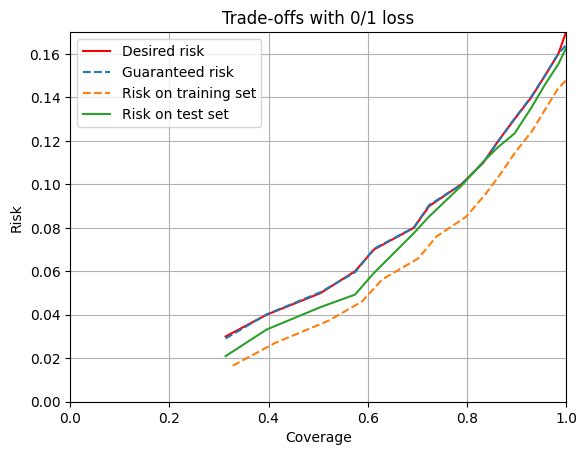

In [11]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with 0/1 loss')
plt.ylim(0,0.17)
plt.xlim(0,1)
plt.legend()
plt.grid()
plt.show()

__Comment__ : 
1) risk cannot be guaranteed below 0.03 in this setting. Indeed it is natural that the classifier reach performance limits on the data : SGR can improve performance with guarantees __up to a certain point__, which can be determined by trade-offs curve.
2) At 100% coverage one can observe the classifier accuracy

### <font color = 'yellow'> 1.2. Evolution of trade-offs as class imbalance increases

In [12]:
sample_size=3500
all_propor_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(sgr_df, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=sample_size)

    train_set = imbalanced_set.iloc[:int(sample_size/2)]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[int(sample_size/2):]

    results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                           delta=0.05, desired_risks=[i/100 for i in range(1,30)])
    results['proportion_1'] = proportion_1/100
    all_propor_dfs = pd.concat([all_propor_dfs, results]).reset_index(drop=True)
    

all_propor_dfs.head()

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.03,0.030139,0.013678,0.376000,0.013223,0.345714,0.01
1,0.04,0.040839,0.022758,0.426857,0.017167,0.399429,0.01
2,0.05,0.051337,0.032445,0.493143,0.024242,0.471429,0.01
3,0.06,0.058764,0.040346,0.594857,0.041791,0.574286,0.01
4,0.07,0.070441,0.051304,0.657143,0.056437,0.648000,0.01


C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\3387945398.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\3387945398.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_orange = cm.get_cmap('Oranges')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\3387945398.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_gray = cm.get_cmap('Grays')


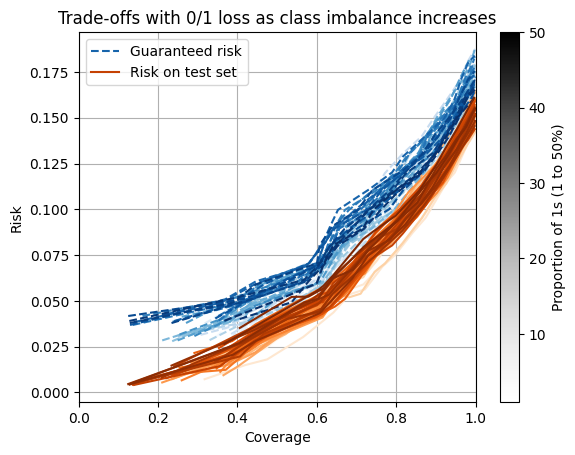

In [13]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_propor_dfs.loc[all_propor_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue, linestyle='--')
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk', linestyle='--')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1s (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with 0/1 loss as class imbalance increases')
plt.grid()
plt.xlim(0, 1)
plt.show()

__Comment__ : no clear effect of imbalance increase

## <font color = 'yellow'> 2. SGR with __type I loss (FP risk)__

### <font color = 'yellow'> 2.1. Risk coverage trade-offs

In [14]:
results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                       delta=0.05, desired_risks=[i/100 for i in range(1,15)], loss = 'typeI')
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.02,0.021227,0.007553,0.378286,0.017153,0.333143
1,0.03,0.030692,0.016465,0.520571,0.028121,0.508000
2,0.04,0.039787,0.025090,0.637714,0.036799,0.621143
3,0.05,0.049450,0.034457,0.762857,0.046225,0.741714
4,0.06,0.059956,0.044728,0.894286,0.057568,0.883429
5,0.07,0.070499,0.054632,0.962286,0.067746,0.953143
6,0.08,0.075596,0.059497,0.998857,0.077453,0.996000
7,0.09,0.075596,0.059497,0.998857,0.077453,0.996000
8,0.10,0.075596,0.059497,0.998857,0.077453,0.996000
9,0.11,0.075596,0.059497,0.998857,0.077453,0.996000


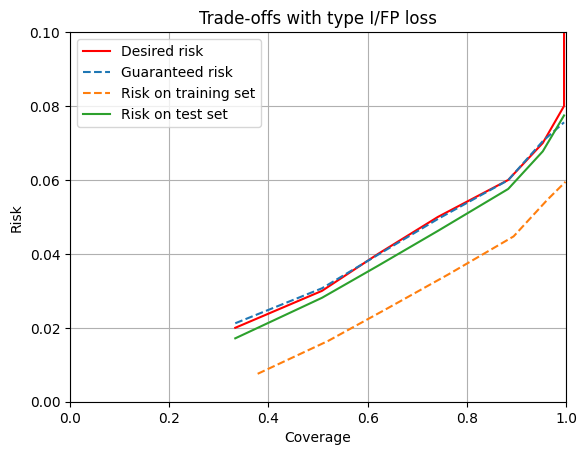

In [15]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.ylim(0,0.1)
plt.xlim(0,1)
plt.legend()
plt.title('Trade-offs with type I/FP loss')
plt.grid()
plt.show()

__Comment__ : fourfold increase of performance at the cost of -70% coverage
1) Best guaranteed performance (left) is <2% of samples classified as FPs, cost is coverage=33%.
2) Performance at 100% coverage would be 8% of samples classified as FPs.

### <font color = 'yellow'> 2.2. Evolution of trade-offs as class imbalance increases

In [16]:
sample_size=3500
all_propor_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(sgr_df, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=sample_size)

    train_set = imbalanced_set.iloc[:int(sample_size/2)]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[int(sample_size/2):]

    results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                           delta=0.05, desired_risks=[i/100 for i in range(1,30)], loss='typeI')
    results['proportion_1'] = proportion_1/100
    all_propor_dfs = pd.concat([all_propor_dfs, results]).reset_index(drop=True)
    
all_propor_dfs.head()

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.03,0.030139,0.013678,0.376000,0.013223,0.345714,0.01
1,0.04,0.040839,0.022758,0.426857,0.017167,0.399429,0.01
2,0.05,0.051337,0.032445,0.493143,0.024242,0.471429,0.01
3,0.06,0.058764,0.040346,0.594857,0.041791,0.574286,0.01
4,0.07,0.070441,0.051304,0.657143,0.056437,0.648000,0.01


C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\3063621568.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\3063621568.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_orange = cm.get_cmap('Oranges')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\3063621568.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_gray = cm.get_cmap('Grays')


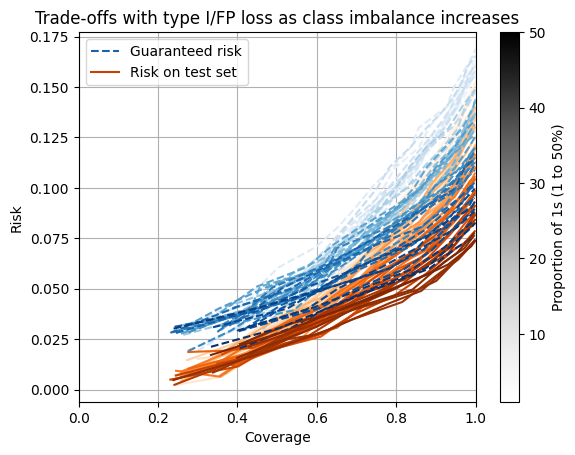

In [17]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_propor_dfs.loc[all_propor_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue, linestyle='--')
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk', linestyle='--')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1s (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with type I/FP loss as class imbalance increases')
plt.grid()
plt.xlim(0, 1)
plt.show()

__Comment__ : class imbalance has effect on trade-offs, 
* as less 1s means higher FP risk at fixed coverage (makes completely sense since classifier output does not change and there are relatively more 0s to commit mistakes on)
* less 1s means steeper risk/coverage evolution, ie stronger class imbalance => more FP risk improvement from the same amount of coverage renouncement

__In other words, class imbalance seems beneficial for Selection with Guaranteed FP Risk__

## <font color = 'yellow'> 3. SGR with __type II loss (FN risk)__

### <font color = 'yellow'> 3.1. Risk coverage trade-offs

In [8]:
results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                       delta=0.001, desired_risks=[i/100 for i in range(1,15)], loss = 'typeII')
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.02,0.021240,0.006000,0.285714,0.013830,0.268571
1,0.03,0.029800,0.015677,0.510286,0.020654,0.498000
2,0.04,0.039963,0.025244,0.645143,0.031934,0.626286
3,0.05,0.049896,0.034727,0.765143,0.052392,0.752571
4,0.06,0.060074,0.044077,0.829714,0.059108,0.826571
5,0.07,0.070160,0.053415,0.882571,0.064506,0.881429
6,0.08,0.080200,0.062862,0.936286,0.074312,0.934286
7,0.09,0.090271,0.072363,0.983143,0.086212,0.984286
8,0.10,0.092255,0.074328,0.999429,0.088883,0.999714
9,0.11,0.092255,0.074328,0.999429,0.088883,0.999714


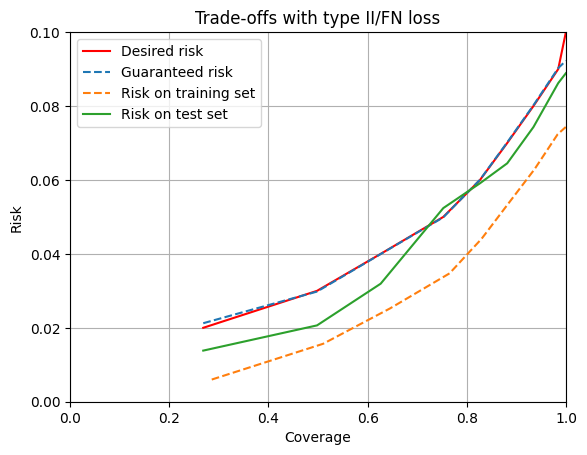

In [9]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.ylim(0,0.1)
plt.xlim(0,1)
plt.legend()
plt.title('Trade-offs with type II/FN loss')
plt.grid()
plt.show()

__Comment__ : fourfold increase of performance at the cost of -40% coverage
1) Best guaranteed performance (left) is <2% of samples classified as FNs, cost is coverage=60%.
2) Performance at 100% coverage would be >8% of samples classified as FNs.

### <font color = 'yellow'> 3.2. Evolution of trade-offs as class imbalance increases

In [20]:
sample_size=3500
all_propor_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(sgr_df, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=sample_size)

    train_set = imbalanced_set.iloc[:int(sample_size/2)]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[int(sample_size/2):]

    results = SGR_at_risks(train_set, test_set, k = int(np.log2(train_set.shape[0])),
                           delta=0.05, desired_risks=[i/100 for i in range(1,30)], loss='typeII')
    results['proportion_1'] = proportion_1/100
    all_propor_dfs = pd.concat([all_propor_dfs, results]).reset_index(drop=True)
    
all_propor_dfs.head()

,proportion_1,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.03,0.01,0.008934,0.003432,0.998857,0.004002,0.999429
1,0.03,0.02,0.008934,0.003432,0.998857,0.004002,0.999429
2,0.03,0.03,0.008934,0.003432,0.998857,0.004002,0.999429
3,0.03,0.04,0.008934,0.003432,0.998857,0.004002,0.999429
4,0.03,0.05,0.008934,0.003432,0.998857,0.004002,0.999429


C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\1440076058.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\1440076058.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_orange = cm.get_cmap('Oranges')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_23204\1440076058.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_gray = cm.get_cmap('Grays')


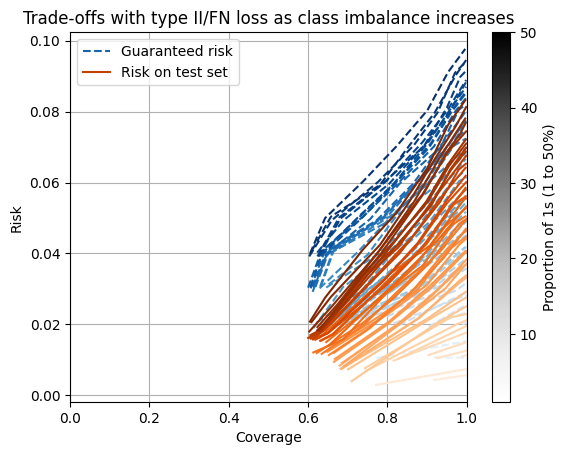

In [21]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_propor_dfs.loc[all_propor_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue, linestyle='--')
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk', linestyle='--')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1s (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with type II/FN loss as class imbalance increases')
plt.grid()
plt.xlim(0, 1)
#plt.ylim(0, 0.1)

plt.show()

__Comment__ : class imbalance has effect on trade-offs, 
* as less 1s means lower FN risk at fixed coverage (makes completely sense since classifier output does not change and there are relatively less 1s to commit mistakes on)
* less 1s means flatter risk/coverage evolution, ie stronger class imbalance => less FN risk improvement from the same amount of coverage renouncement

__In other words, class imbalance seems detrimental to Selection with Guaranteed FN Risk__